In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

df=pd.read_csv(r"C:\Users\Samaira Singh\Downloads\Data.csv")
df.info()
df.describe()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3457 entries, 0 to 3456
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3457 non-null   float64
 1   Sensor1      3457 non-null   float64
 2   Sensor2      3457 non-null   float64
 3   Sensor3      3457 non-null   float64
 4   Sensor4      3457 non-null   float64
 5   Sensor5      3457 non-null   float64
dtypes: float64(6)
memory usage: 162.2 KB
   Temperature   Sensor1   Sensor2   Sensor3   Sensor4   Sensor5
0    25.431489  0.677916  0.208399  0.033098  0.145758  0.291933
1    24.486056  0.801851  0.445989  0.869082  0.499015  0.531490
2    20.055087  0.781817  0.040596  0.205773  0.517225  0.598457
3    22.781690  0.651030  0.316018  0.945797  0.433242  0.378673
4    25.292826  0.292357  0.893463  0.289188  0.490347  0.012502


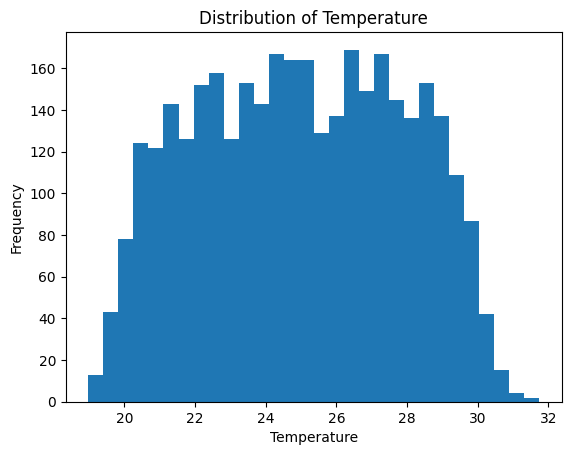

In [2]:
df["Temperature"].hist(bins=30)
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.title("Distribution of Temperature")
plt.grid(False)
plt.show()


In [3]:
corr = df.corr(method ="pearson")
print(corr["Temperature"].sort_values(ascending=False))

Temperature    1.000000
Sensor5        0.018677
Sensor1        0.016421
Sensor4        0.005499
Sensor2       -0.010137
Sensor3       -0.018427
Name: Temperature, dtype: float64


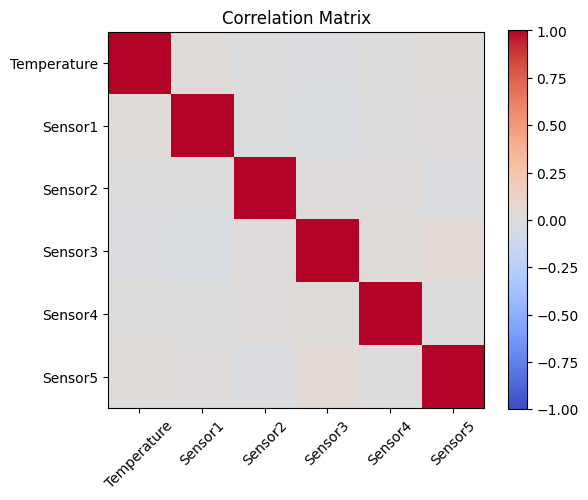

In [4]:
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

weakly correlated features imply relatinship isnt linear therefore using spearman to check for monotonicity

In [5]:
corr_spearman = df.corr(method="spearman")
print(corr_spearman["Temperature"].sort_values(ascending=False))

Temperature    1.000000
Sensor5        0.018277
Sensor1        0.015760
Sensor4        0.004731
Sensor2       -0.010415
Sensor3       -0.018698
Name: Temperature, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Temperature"])
y = df["Temperature"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42  # ~15% of original
)

print(X_train.shape, X_val.shape, X_test.shape)

(2419, 5) (519, 5) (519, 5)


In [7]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_val)

mae = mean_absolute_error(y_val, pred_dummy)
rmse = np.sqrt(mean_squared_error(y_val, pred_dummy))
r2 = r2_score(y_val, pred_dummy)
print("Dummy:", mae, rmse, r2)

Dummy: 2.4699713803094023 2.886914135670608 -0.00011952314541874287


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

In [9]:
def evaluate(model, X_val, y_val, name):
    pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2 = r2_score(y_val, pred)
    print(f"{name}: MAE={mae:.4f} RMSE={rmse:.4f} R2={r2:.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

In [10]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),   #building the structure of pipeline 
    ("model", LinearRegression())
])

In [11]:
lr_pipe.fit(X_train, y_train)   

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [12]:
results_lr = evaluate(lr_pipe, X_val, y_val, "LinearRegression")

LinearRegression: MAE=2.4760 RMSE=2.8928 R2=-0.0042


In [15]:
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))
])
ridge_pipe.fit(X_train, y_train)
results_ridge = evaluate(ridge_pipe, X_val, y_val, "Ridge")

Ridge: MAE=2.4760 RMSE=2.8928 R2=-0.0042


In [21]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Decision Tree
dt_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeRegressor(max_depth=5, random_state=42))
])
dt_pipe.fit(X_train, y_train)
results_dt = evaluate(dt_pipe, X_val, y_val, "DecisionTree")

# Random Forest
rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42))
])
rf_pipe.fit(X_train, y_train)
results_rf = evaluate(rf_pipe, X_val, y_val, "RandomForest")

DecisionTree: MAE=2.5087 RMSE=2.9658 R2=-0.0556
RandomForest: MAE=2.4606 RMSE=2.8793 R2=0.0051


In [14]:
train_pred = dt_pipe.predict(X_train)
print("DT train R2:", r2_score(y_train, train_pred))
print("DT val R2:", results_dt["R2"])

DT train R2: 0.045162949508851136
DT val R2: -0.05555737392868276


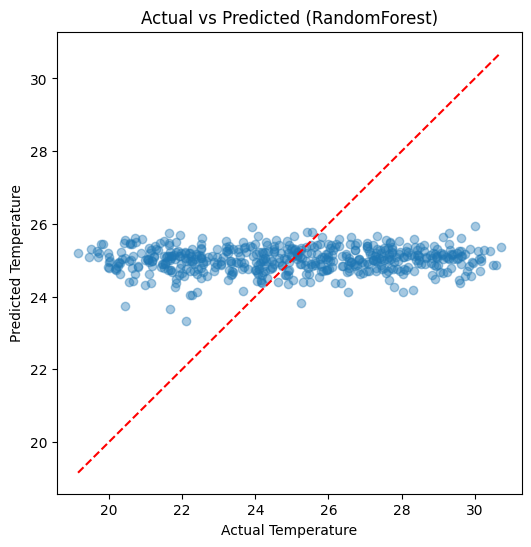

In [16]:
rf_val_pred = rf_pipe.predict(X_val)

plt.figure(figsize=(6,6))
plt.scatter(y_val, rf_val_pred, alpha=0.4)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')  # perfect-prediction line
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted (RandomForest)")
plt.show()

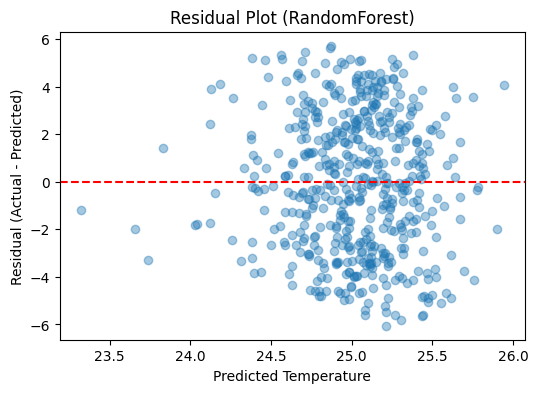

In [17]:
# Residual plot
residuals = y_val - rf_val_pred

plt.figure(figsize=(6,4))
plt.scatter(rf_val_pred, residuals, alpha=0.4)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Temperature")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (RandomForest)")
plt.show()

In [18]:
val_results = pd.DataFrame({
    "actual": y_val.values,
    "predicted": rf_val_pred,
})
val_results["abs_error"] = (val_results["actual"] - val_results["predicted"]).abs()

worst = val_results.sort_values("abs_error", ascending=False).head(15)
print(worst)

        actual  predicted  abs_error
424  19.157888  25.211798   6.053911
46   19.510953  25.305136   5.794183
390  30.584734  24.870391   5.714343
21   30.505541  24.866112   5.639429
478  19.795644  25.434181   5.638536
39   19.457032  25.079858   5.622826
270  19.828434  25.438947   5.610513
182  19.673706  25.267167   5.593461
3    19.727484  25.212175   5.484691
344  30.151013  24.707147   5.443866
35   19.704751  25.081463   5.376712
447  30.706409  25.377422   5.328986
438  29.881323  24.563037   5.318285
442  19.964625  25.203081   5.238456
84   29.593608  24.382953   5.210654


In [19]:
worst.to_csv("high_error_predictions.csv", index=False)

In [22]:
rf_train_pred = rf_pipe.predict(X_train)
print("RF train R2:", r2_score(y_train, rf_train_pred))
print("RF val R2:", results_rf["R2"])

RF train R2: 0.054005375151885526
RF val R2: 0.005117198565513403


In [23]:
import joblib

joblib.dump(rf_pipe, "final_regression_pipeline.joblib")

['final_regression_pipeline.joblib']

In [24]:
import sys

def load_model(model_path="final_regression_pipeline.joblib"):
    return joblib.load(model_path)

def predict_from_csv(model, input_csv):
    new_data = pd.read_csv(input_csv)
    predictions = model.predict(new_data)
    new_data["Predicted_Temperature"] = predictions
    return new_data

def predict_single(model, sensor_values: dict):
    df_row = pd.DataFrame([sensor_values])
    return model.predict(df_row)[0]

if __name__ == "__main__":
    model = load_model()

    if len(sys.argv) > 1:
        input_path = sys.argv[1]
        result = predict_from_csv(model, input_path)
        print(result)
        result.to_csv("predictions_output.csv", index=False)
    else:
        example = {
            "Sensor1": 0.5,
            "Sensor2": 0.5,
            "Sensor3": 0.5,
            "Sensor4": 0.5,
            "Sensor5": 0.5,
        }
        pred = predict_single(model, example)
        print(f"Predicted Temperature: {pred:.2f}")

OSError: [Errno 22] Invalid argument: '--f="c:\\Users\\Samaira Singh\\AppData\\Roaming\\jupyter\\runtime\\kernel-v3fc07edc60fa1447c6bf52c054fb9605b04c063bb.json"'